In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
     

In [16]:
df = pd.read_csv(
    "Movie.zip",
    encoding='latin1'
)

df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [8]:
df_movie.describe()

,"Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3"
count,15509
unique,15503
top,"Shivani,(2019),,Crime,,,Ugresh Prasad Ujala,Sa..."
freq,2


In [18]:
df.isnull().sum()


Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [19]:
df.dropna(inplace=True)

In [20]:
df['Rating'] = pd.to_numeric(
    df['Rating'],
    errors='coerce'
)

In [21]:
df.dropna(inplace=True)

In [22]:
df = df[
    [
        'Genre',
        'Director',
        'Actor 1',
        'Actor 2',
        'Actor 3',
        'Rating'
    ]
]

df.head()

,Genre,Director,Actor 1,Actor 2,Actor 3,Rating
1,Drama,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,7.0
3,"Comedy, Romance",Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,4.4
5,"Comedy, Drama, Musical",Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,4.7
6,"Drama, Romance, War",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,7.4
8,"Horror, Mystery, Thriller",Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,5.6


In [23]:
le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])

df['Director'] = le.fit_transform(df['Director'])

df['Actor 1'] = le.fit_transform(df['Actor 1'])

df['Actor 2'] = le.fit_transform(df['Actor 2'])

df['Actor 3'] = le.fit_transform(df['Actor 3'])

In [24]:
X = df.drop('Rating', axis=1)

y = df['Rating']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred = model.predict(X_test)

y_pred[:10]

array([6.162, 6.406, 6.478, 5.281, 7.054, 4.761, 6.045, 6.1  , 6.121,
       6.608])

In [28]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error :", mae)

Mean Absolute Error : 1.052870597762073


In [29]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error :", mse)

Mean Squared Error : 1.755117969203229


In [30]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : 0.0521809145287625


In [31]:
results = pd.DataFrame({
    'Actual Rating': y_test,
    'Predicted Rating': y_pred
})

results.head(10)

,Actual Rating,Predicted Rating
10971,6.0,6.162
14052,2.4,6.406
10002,3.8,6.478
3970,3.8,5.281
8840,7.2,7.054
5071,6.3,4.761
2709,8.6,6.045
11842,3.9,6.100
10910,6.6,6.121
4485,6.6,6.608


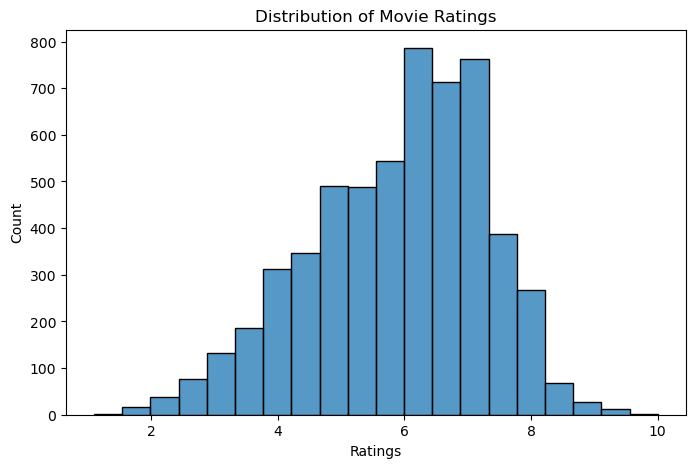

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(df['Rating'], bins=20)

plt.title("Distribution of Movie Ratings")

plt.xlabel("Ratings")

plt.ylabel("Count")

plt.show()

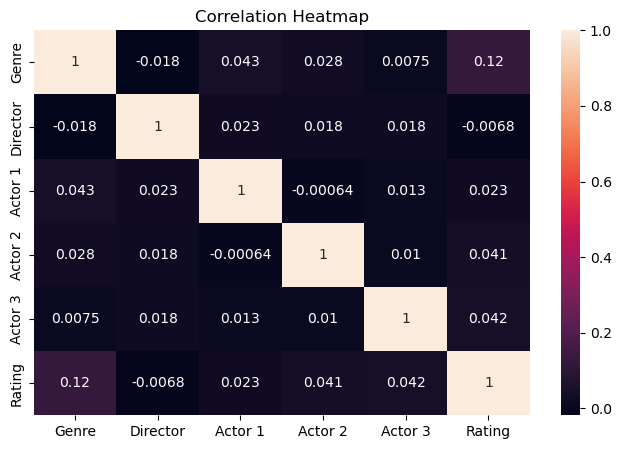

In [33]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

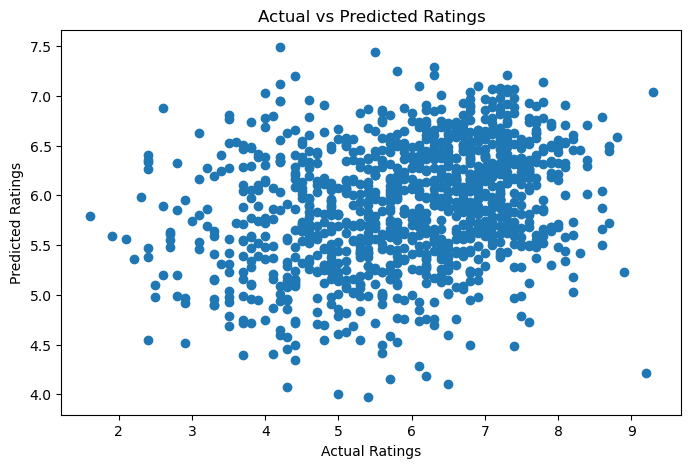

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")

plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings")

plt.show()

In [35]:
importance = model.feature_importances_

features = X.columns

feature_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_df = feature_df.sort_values(
    by='Importance',
    ascending=False
)

feature_df

,Feature,Importance
2,Actor 1,0.204165
0,Genre,0.201684
1,Director,0.201595
4,Actor 3,0.197737
3,Actor 2,0.194819


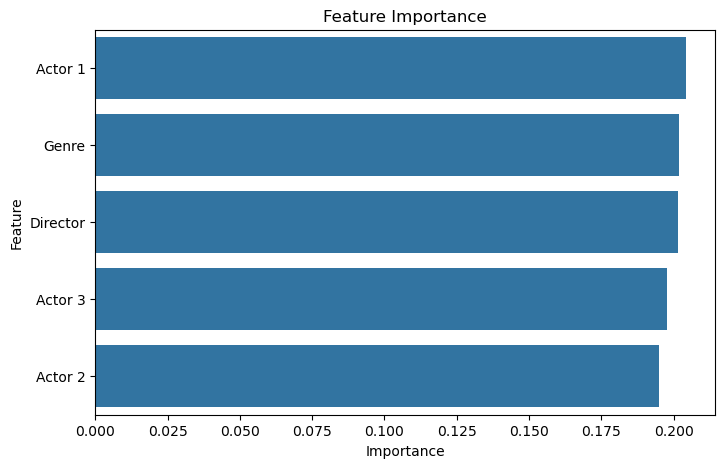

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df
)

plt.title("Feature Importance")

plt.show()